In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Drug–Target Interaction Prediction using Graph Neural Networks and Protein Language Models

## Motivation

Drug discovery is one of the most expensive and time-consuming processes in biomedical research. Experimental screening of every possible drug against every possible protein is impractical.

Drug–Target Interaction (DTI) prediction aims to computationally estimate whether a drug molecule interacts with a target protein. Accurate prediction of these interactions accelerates drug discovery, drug repurposing, and personalized medicine.

---

## Objective

Develop a deep learning framework that predicts the interaction between drugs and proteins by combining:

- Graph Neural Networks (GNNs) for molecular graph representation.
- Protein Language Models (ESM2) for protein sequence representation.
- A multimodal neural network for interaction prediction.

---

## Learning Objectives

Throughout this project, we will learn:

- Molecular graph construction
- Graph Neural Networks
- Protein Language Models
- Representation Learning
- Multimodal Deep Learning
- Drug Discovery
- Explainable AI

---

## Dataset

We use the **Davis Drug–Target Interaction Dataset**, a benchmark dataset widely used for evaluating DTI prediction models.

---

## Workflow

Drug (SMILES)
        │
        ▼
RDKit
        │
        ▼
Molecular Graph
        │
        ▼
Graph Neural Network
        │
        ▼
Drug Embedding
                    │
                    ▼
             Feature Fusion
                    ▲
                    │
Protein Sequence    │
        │           │
      ESM2          │
        │           │
Protein Embedding   │
                    ▼
          Interaction Prediction

## Environment Setup

This notebook is designed for execution on Kaggle using a Tesla T4 GPU.

Main libraries:

- PyTorch
- PyTorch Geometric
- RDKit
- Transformers
- Pandas
- NumPy
- Scikit-Learn

In [2]:
##############################################################
# 2.1 Install Dependencies
##############################################################

!pip -q install torch-geometric
!pip -q install rdkit
!pip -q install transformers
!pip -q install accelerate 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 51.3 MB/s eta 0:00:00:00:0100:01


In [3]:
##############################################################
# Install Biopython
##############################################################

!pip install -q biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 43.8 MB/s eta 0:00:0000:0100:01


In [4]:
##############################################################
# 2.2 Imports
##############################################################

import os
import gc
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch

warnings.filterwarnings("ignore")

In [5]:
##############################################################
# Biopython Imports
##############################################################

from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import molecular_weight

print("Biopython installed successfully!")

Biopython installed successfully!


In [6]:
from pathlib import Path

checkpoint_dir = Path(CHECKPOINT_DIR)

deleted = 0

for file in checkpoint_dir.glob("*.pt"):
    file.unlink()
    print(f"Deleted: {file.name}")
    deleted += 1

print(f"\nTotal checkpoint files deleted: {deleted}")

NameError: name 'CHECKPOINT_DIR' is not defined

In [7]:
##############################################################
# 2.3 Reproducibility
##############################################################

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

In [8]:
##############################################################
# 2.4 Device Information
##############################################################

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("="*60)

print("Device :", device)

if torch.cuda.is_available():

    print("GPU :", torch.cuda.get_device_name(0))

    print(
        f"GPU Memory : "
        f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.2f} GB"
    )

print("="*60)

Device : cuda
GPU : Tesla T4
GPU Memory : 14.56 GB


In [9]:
##############################################################
# 2.5 Directory Structure
##############################################################

PROJECT_ROOT = Path("DTI_Project")

RAW_DIR = PROJECT_ROOT / "raw"

PROCESSED_DIR = PROJECT_ROOT / "processed"

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

MODEL_DIR = PROJECT_ROOT / "models"

FIGURE_DIR = PROJECT_ROOT / "figures"

for directory in [

    PROJECT_ROOT,

    RAW_DIR,

    PROCESSED_DIR,

    ARTIFACT_DIR,

    MODEL_DIR,

    FIGURE_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Project folders created successfully.")

Project folders created successfully.


# Section 3: Loading the Davis Dataset

In this section we load the raw Davis dataset and inspect its contents before performing any preprocessing.

The dataset consists of:

- Drug molecules represented as SMILES strings.
- Protein sequences.
- Drug–protein binding affinity matrix.
- Official train/test folds used in the DeepDTA benchmark.

At this stage, no preprocessing is performed. We only verify that the dataset has been loaded correctly.

In [10]:
##############################################################
# 3.1 Imports
##############################################################

import json
import pickle

from pathlib import Path

import numpy as np
import pandas as pd

In [11]:
##############################################################
# 3.2 Dataset Path
##############################################################

DATASET_ROOT = Path("/kaggle/working/DeepDTA/data/davis")

print(DATASET_ROOT)

/kaggle/working/DeepDTA/data/davis


In [12]:
##############################################################
# Download Davis Dataset
##############################################################

!git clone https://github.com/hkmztrk/DeepDTA.git

Cloning into 'DeepDTA'...
remote: Enumerating objects: 442, done.
remote: Counting objects: 100% (44/44), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 442 (delta 33), reused 32 (delta 29), pack-reused 398 (from 1)
Receiving objects: 100% (442/442), 10.99 MiB | 22.19 MiB/s, done.
Resolving deltas: 100% (174/174), done.


In [13]:
##############################################################
# 3.3 Load Drug Molecules
##############################################################

drug_file = DATASET_ROOT / "ligands_can.txt"

with open(drug_file, "r") as f:
    drugs = json.load(f)

drug_df = pd.DataFrame({
    "Drug_ID": list(drugs.keys()),
    "SMILES": list(drugs.values())
})

print("=" * 60)
print("Drug Dataset")
print("=" * 60)

print(f"Number of Drugs : {len(drug_df)}")

drug_df.head()

Drug Dataset
Number of Drugs : 68


,Drug_ID,SMILES
0,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...
1,24889392,CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C...
2,11409972,CCN1CCN(CC1)CC2=C(C=C(C=C2)NC(=O)NC3=CC=C(C=C3...
3,11338033,C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl
4,10184653,CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(...


In [14]:
##############################################################
# 3.4 Load Protein Sequences
##############################################################

protein_file = DATASET_ROOT / "proteins.txt"

with open(protein_file, "r") as f:
    proteins = json.load(f)

protein_df = pd.DataFrame({
    "Protein_ID": list(proteins.keys()),
    "Sequence": list(proteins.values())
})

print("=" * 60)
print("Protein Dataset")
print("=" * 60)

print(f"Number of Proteins : {len(protein_df)}")

protein_df.head()

Protein Dataset
Number of Proteins : 442


,Protein_ID,Sequence
0,AAK1,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...
1,ABL1(E255K),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
2,ABL1(F317I),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
3,ABL1(F317I)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...
4,ABL1(F317L),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...


In [15]:
##############################################################
# 3.5 Load Binding Affinity Matrix
##############################################################

import pickle
import numpy as np

affinity_file = DATASET_ROOT / "Y"

with open(affinity_file, "rb") as f:
    affinity_matrix = pickle.load(
        f,
        encoding="latin1"
    )

affinity_matrix = np.array(affinity_matrix)

print("=" * 60)
print("Binding Affinity Matrix")
print("=" * 60)

print("Shape :", affinity_matrix.shape)
print("Data Type :", affinity_matrix.dtype)

Binding Affinity Matrix
Shape : (68, 442)
Data Type : float64


In [16]:
##############################################################
# 3.8 Load Official Train/Test Splits
##############################################################

fold_path = DATASET_ROOT / "folds"

with open(fold_path / "train_fold_setting1.txt") as f:
    train_folds = json.load(f)

with open(fold_path / "test_fold_setting1.txt") as f:
    test_fold = json.load(f)

print("=" * 60)
print("Official Dataset Splits")
print("=" * 60)

print(f"Training Folds : {len(train_folds)}")
print(f"Test Samples   : {len(test_fold)}")

Official Dataset Splits
Training Folds : 5
Test Samples   : 5010


## 4.1 Dataset Dimensions

Before building a deep learning model, it is useful to understand the overall size of the dataset.

The Davis dataset consists of:

- Drug molecules
- Protein targets
- Drug–protein interaction matrix

This provides an overview of the prediction problem.

In [17]:
##############################################################
# 4.1 Dataset Dimensions
##############################################################

print("=" * 60)
print("Dataset Dimensions")
print("=" * 60)

print(f"Number of Drugs      : {len(drug_df):,}")
print(f"Number of Proteins   : {len(protein_df):,}")
print(f"Affinity Matrix Size : {affinity_matrix.shape}")
print(f"Possible Interactions: {affinity_matrix.size:,}")

Dataset Dimensions
Number of Drugs      : 68
Number of Proteins   : 442
Affinity Matrix Size : (68, 442)
Possible Interactions: 30,056


## 4.2 Drug Statistics

Each drug is represented using a SMILES string.

A SMILES string is a textual representation of a molecular structure.

We first inspect a few examples before converting them into molecular graphs.

In [18]:
##############################################################
# 4.2 Drug Statistics
##############################################################

drug_df["SMILES_Length"] = drug_df["SMILES"].str.len()

display(drug_df.head())

print()

print(drug_df["SMILES_Length"].describe())

,Drug_ID,SMILES,SMILES_Length
0,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,51
1,24889392,CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C...,77
2,11409972,CCN1CCN(CC1)CC2=C(C=C(C=C2)NC(=O)NC3=CC=C(C=C3...,72
3,11338033,C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl,48
4,10184653,CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(...,67



count    68.000000
mean     62.779412
std      12.259441
min      39.000000
25%      53.750000
50%      60.500000
75%      72.000000
max      92.000000
Name: SMILES_Length, dtype: float64


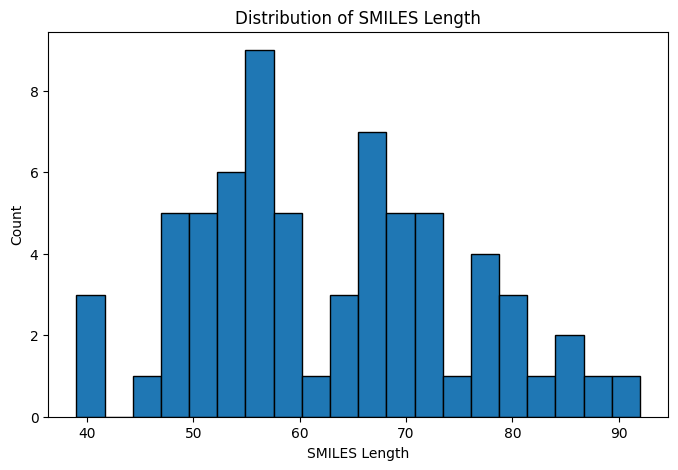

In [19]:
##############################################################
# 4.3 SMILES Length Distribution
##############################################################

plt.figure(figsize=(8,5))

plt.hist(
    drug_df["SMILES_Length"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("SMILES Length")

plt.ylabel("Count")

plt.title("Distribution of SMILES Length")

plt.show()

## 4.4 Protein Statistics

Each protein is represented by its amino acid sequence.

The sequence length varies considerably across proteins.

Understanding this distribution helps determine the maximum sequence length required for the protein encoder.

In [20]:
##############################################################
# 4.4 Protein Statistics
##############################################################

protein_df["Sequence_Length"] = protein_df["Sequence"].str.len()

display(protein_df.head())

print()

print(protein_df["Sequence_Length"].describe())

,Protein_ID,Sequence,Sequence_Length
0,AAK1,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...,961
1,ABL1(E255K),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167
2,ABL1(F317I),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167
3,ABL1(F317I)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167
4,ABL1(F317L),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167



count     442.000000
mean      788.947964
std       378.767663
min       244.000000
25%       488.750000
50%       707.000000
75%      1015.000000
max      2549.000000
Name: Sequence_Length, dtype: float64


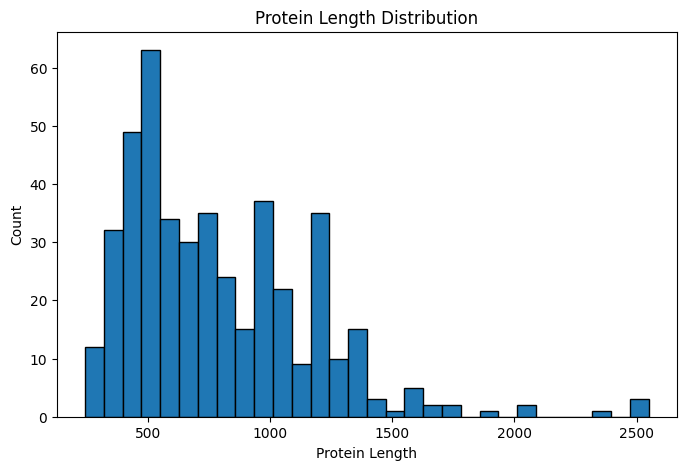

In [21]:
##############################################################
# 4.5 Protein Length Distribution
##############################################################

plt.figure(figsize=(8,5))

plt.hist(
    protein_df["Sequence_Length"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Protein Length")

plt.ylabel("Count")

plt.title("Protein Length Distribution")

plt.show()

In [22]:
##############################################################
# 4.6 Affinity Statistics
##############################################################

##############################################################
# Affinity Statistics (All Interactions)
##############################################################

valid_affinity = affinity_matrix.flatten()

print("=" * 60)
print("Affinity Statistics")
print("=" * 60)
print(f"Total interactions : {len(valid_affinity):,}")
print(f"Minimum affinity   : {valid_affinity.min():.4f}")
print(f"Maximum affinity   : {valid_affinity.max():.4f}")
print(f"Mean affinity      : {valid_affinity.mean():.4f}")
print(f"Median affinity    : {np.median(valid_affinity):.4f}")

Affinity Statistics
Total interactions : 30,056
Minimum affinity   : 0.0160
Maximum affinity   : 10000.0000
Mean affinity      : 7415.8766
Median affinity    : 10000.0000


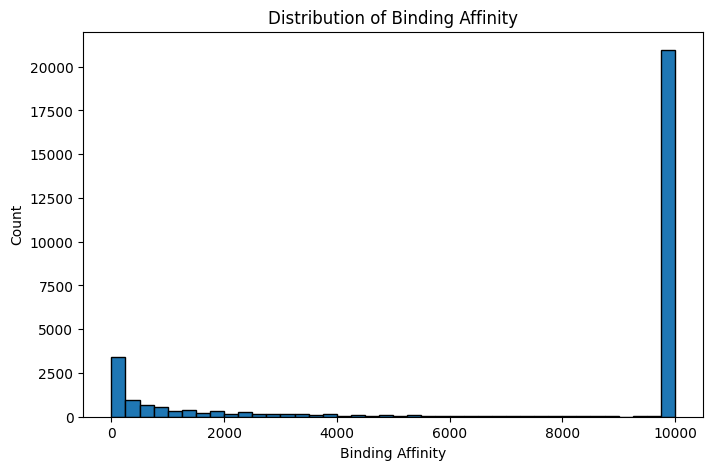

In [23]:
##############################################################
# 4.7 Affinity Distribution
##############################################################

plt.figure(figsize=(8,5))

plt.hist(
    valid_affinity,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Binding Affinity")

plt.ylabel("Count")

plt.title("Distribution of Binding Affinity")

plt.show()

In [24]:
##############################################################
# 4.8 Missing Values
##############################################################

missing = np.isnan(affinity_matrix)

print("="*60)

print("Missing Values")

print("="*60)

print(f"Missing Entries : {missing.sum():,}")

print(f"Observed Entries: {(~missing).sum():,}")

Missing Values
Missing Entries : 0
Observed Entries: 30,056


In [25]:
##############################################################
# 4.9 Duplicate Check
##############################################################

print("="*60)

print("Duplicate Check")

print("="*60)

print("Duplicate Drugs   :", drug_df.duplicated("SMILES").sum())

print("Duplicate Proteins:", protein_df.duplicated("Sequence").sum())

Duplicate Check
Duplicate Drugs   : 0
Duplicate Proteins: 63


# Section 5: Drug Molecular Analysis

SMILES strings are compact textual representations of molecules.

Before converting them into graph structures for a Graph Neural Network, we first analyze their chemical properties.

Using RDKit, each SMILES string is converted into a molecular object from which various physicochemical descriptors are extracted.

These descriptors help us understand the diversity and complexity of the dataset and are commonly used in cheminformatics.

In [26]:
import sys

print(sys.executable)

!pip show rdkit

/usr/bin/python3
Name: rdkit
Version: 2026.3.5
Summary: A collection of chemoinformatics and machine-learning software written in C++ and Python
Home-page: https://github.com/kuelumbus/rdkit-pypi
Author: Christopher Kuenneth
Author-email: chris@kuenneth.dev
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: numpy, Pillow
Required-by: 


In [27]:
##############################################################
# 5.1 RDKit Imports
##############################################################

from rdkit import Chem

from rdkit.Chem import Descriptors

from rdkit.Chem import Lipinski

from rdkit.Chem import rdMolDescriptors

In [28]:
##############################################################
# 5.2 Convert SMILES into RDKit Molecules
##############################################################

drug_df["Molecule"] = drug_df["SMILES"].apply(
    Chem.MolFromSmiles
)

invalid = drug_df["Molecule"].isnull().sum()

print("=" * 60)
print("SMILES Conversion")
print("=" * 60)

print(f"Total Drugs      : {len(drug_df)}")
print(f"Valid Molecules  : {len(drug_df)-invalid}")
print(f"Invalid Molecules: {invalid}")

SMILES Conversion
Total Drugs      : 68
Valid Molecules  : 68
Invalid Molecules: 0


In [29]:
##############################################################
# 5.3 Extract Molecular Descriptors
##############################################################

def molecular_features(mol):

    return pd.Series({

        "NumAtoms": mol.GetNumAtoms(),

        "NumBonds": mol.GetNumBonds(),

        "MolWeight": Descriptors.MolWt(mol),

        "LogP": Descriptors.MolLogP(mol),

        "TPSA": rdMolDescriptors.CalcTPSA(mol),

        "RotatableBonds": Lipinski.NumRotatableBonds(mol),

        "HDonors": Lipinski.NumHDonors(mol),

        "HAcceptors": Lipinski.NumHAcceptors(mol),

        "Rings": rdMolDescriptors.CalcNumRings(mol)

    })

features = drug_df["Molecule"].apply(
    molecular_features
)

drug_df = pd.concat(
    [drug_df, features],
    axis=1
)

In [30]:
##############################################################
# 5.4 Drug Feature Table
##############################################################

display(
    drug_df.head()
)

,Drug_ID,SMILES,SMILES_Length,Molecule,NumAtoms,NumBonds,MolWeight,LogP,TPSA,RotatableBonds,HDonors,HAcceptors,Rings
0,11314340,CC1=C2C=C(C=CC2=NN1)C3=CC(=CN=C3)OCC(CC4=CC=CC...,51,<rdkit.Chem.rdchem.Mol object at 0x7d7522d2cc10>,27.0,30.0,358.445,3.88212,76.82,6.0,2.0,4.0,4.0
1,24889392,CC(C)(C)C1=CC(=NO1)NC(=O)NC2=CC=C(C=C2)C3=CN4C...,77,<rdkit.Chem.rdchem.Mol object at 0x7d7522d2cc80>,40.0,45.0,560.680,5.85650,106.16,7.0,2.0,8.0,6.0
2,11409972,CCN1CCN(CC1)CC2=C(C=C(C=C2)NC(=O)NC3=CC=C(C=C3...,72,<rdkit.Chem.rdchem.Mol object at 0x7d7522d2ce40>,38.0,41.0,529.567,5.11090,94.65,8.0,3.0,7.0,4.0
3,11338033,C1CNCCC1NC(=O)C2=C(C=NN2)NC(=O)C3=C(C=CC=C3Cl)Cl,48,<rdkit.Chem.rdchem.Mol object at 0x7d7522d2cf20>,25.0,27.0,382.251,2.45060,98.91,4.0,4.0,4.0,3.0
4,10184653,CN(C)CC=CC(=O)NC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC(...,67,<rdkit.Chem.rdchem.Mol object at 0x7d7522d2ceb0>,34.0,37.0,485.947,4.38990,88.61,8.0,2.0,7.0,4.0


In [31]:
##############################################################
# 5.5 Descriptor Statistics
##############################################################

columns = [

    "NumAtoms",

    "NumBonds",

    "MolWeight",

    "LogP",

    "TPSA",

    "RotatableBonds",

    "HDonors",

    "HAcceptors",

    "Rings"

]

drug_df[columns].describe()

,NumAtoms,NumBonds,MolWeight,LogP,TPSA,RotatableBonds,HDonors,HAcceptors,Rings
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,32.058824,35.441176,452.846926,4.065158,90.910294,5.661765,2.132353,5.941176,4.455882
std,6.260233,7.090844,86.670969,1.497843,26.846817,2.773060,1.035265,2.006574,1.226983
min,19.000000,21.000000,277.755000,-0.819500,39.340000,1.000000,0.000000,2.000000,3.000000
25%,27.000000,30.000000,379.765250,3.284500,74.495000,3.750000,1.000000,4.000000,4.000000
50%,31.500000,34.000000,454.100500,4.304710,88.510000,5.000000,2.000000,6.000000,4.000000
75%,37.000000,41.000000,516.318000,5.056075,102.930000,7.000000,3.000000,7.250000,5.000000
max,46.000000,51.000000,641.621000,6.931900,183.120000,13.000000,5.000000,12.000000,9.000000


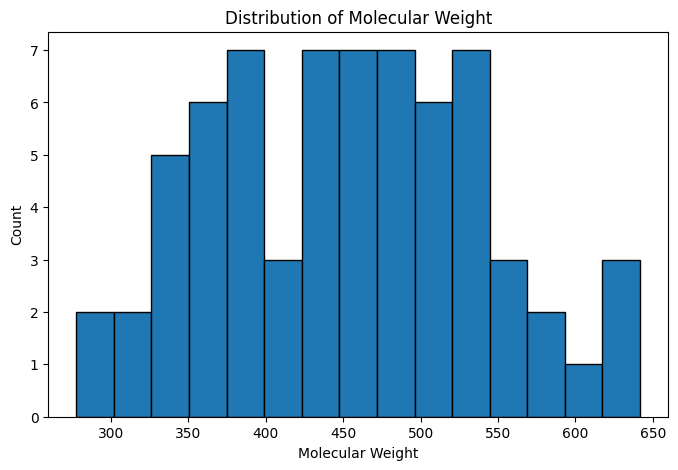

In [32]:
##############################################################
# 5.6 Molecular Weight
##############################################################

plt.figure(figsize=(8,5))

plt.hist(
    drug_df["MolWeight"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Molecular Weight")

plt.ylabel("Count")

plt.title("Distribution of Molecular Weight")

plt.show()

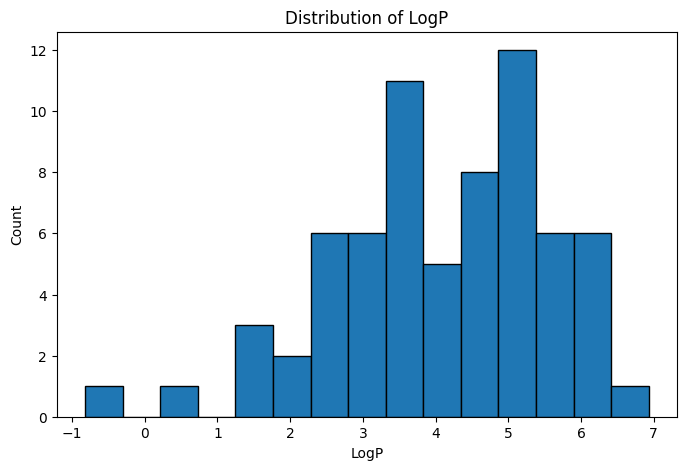

In [33]:
##############################################################
# 5.7 LogP
##############################################################

plt.figure(figsize=(8,5))

plt.hist(
    drug_df["LogP"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("LogP")

plt.ylabel("Count")

plt.title("Distribution of LogP")

plt.show()

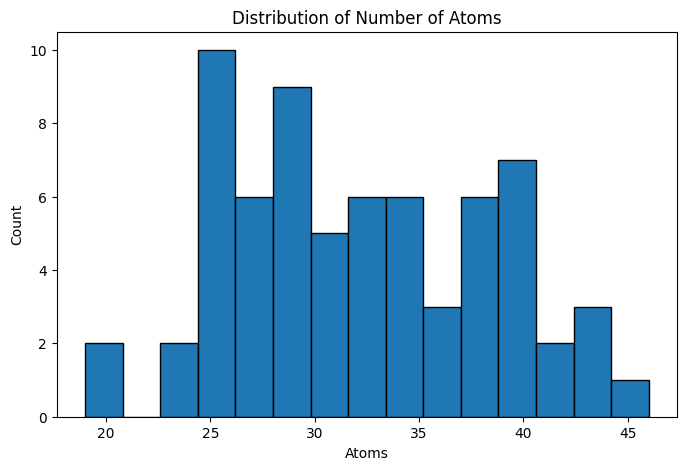

In [34]:
##############################################################
# 5.8 Number of Atoms
##############################################################

plt.figure(figsize=(8,5))

plt.hist(
    drug_df["NumAtoms"],
    bins=15,
    edgecolor="black"
)

plt.xlabel("Atoms")

plt.ylabel("Count")

plt.title("Distribution of Number of Atoms")

plt.show()

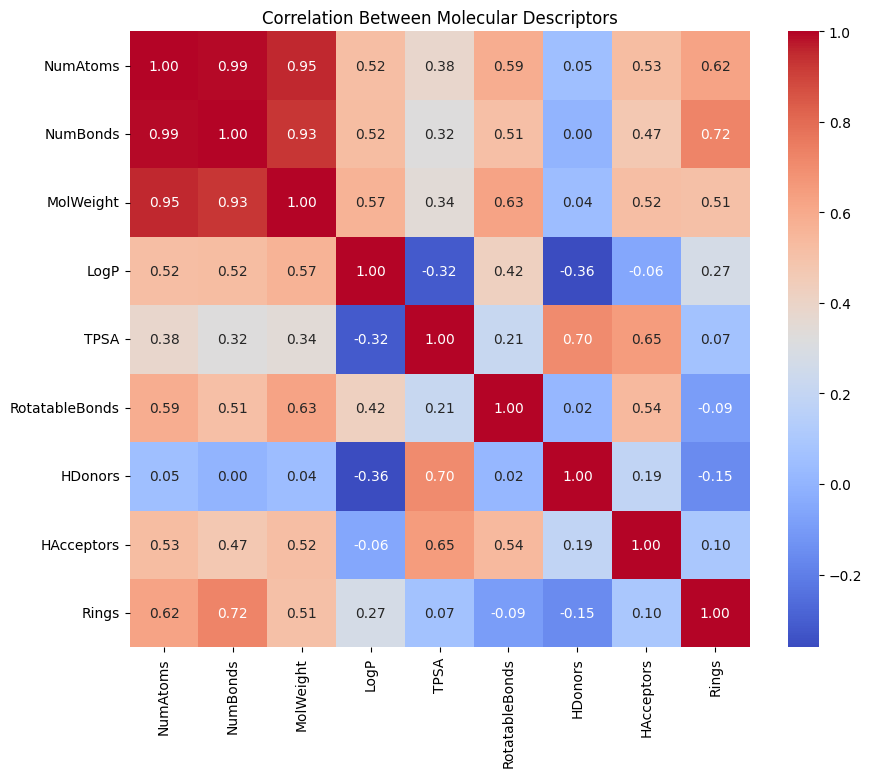

In [35]:
##############################################################
# 5.9 Correlation Matrix
##############################################################

corr = drug_df[columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Molecular Descriptors")

plt.show()

In [36]:
##############################################################
# 5.10 Drug Diversity
##############################################################

print("=" * 60)
print("Drug Diversity")
print("=" * 60)

for col in columns:

    print(
        f"{col:<18}"
        f" Min = {drug_df[col].min():8.2f}"
        f" Max = {drug_df[col].max():8.2f}"
        f" Mean = {drug_df[col].mean():8.2f}"
    )

Drug Diversity
NumAtoms           Min =    19.00 Max =    46.00 Mean =    32.06
NumBonds           Min =    21.00 Max =    51.00 Mean =    35.44
MolWeight          Min =   277.75 Max =   641.62 Mean =   452.85
LogP               Min =    -0.82 Max =     6.93 Mean =     4.07
TPSA               Min =    39.34 Max =   183.12 Mean =    90.91
RotatableBonds     Min =     1.00 Max =    13.00 Mean =     5.66
HDonors            Min =     0.00 Max =     5.00 Mean =     2.13
HAcceptors         Min =     2.00 Max =    12.00 Mean =     5.94
Rings              Min =     3.00 Max =     9.00 Mean =     4.46


# Section 6: Protein Sequence Analysis

The Davis dataset represents each target as an amino acid sequence.

Unlike traditional bioinformatics pipelines, this project uses the pretrained ESM2 protein language model to learn protein representations directly from the raw sequence.

Therefore, instead of manually engineering biochemical descriptors, this section focuses on:

- Protein sequence statistics
- Sequence length analysis
- Amino acid composition
- Sequence quality assessment
- Preparation for ESM2 embeddings

These analyses help us understand the biological characteristics of the dataset while keeping the preprocessing aligned with modern protein foundation models.

In [37]:
##############################################################
# 6.1 Imports
##############################################################

from collections import Counter

In [38]:
##############################################################
# 6.2 Protein Sequence Length
##############################################################

protein_df["Sequence_Length"] = protein_df["Sequence"].str.len()

print("=" * 60)
print("Protein Sequence Statistics")
print("=" * 60)

display(protein_df.head())

print()

print(protein_df["Sequence_Length"].describe())

Protein Sequence Statistics


,Protein_ID,Sequence,Sequence_Length
0,AAK1,MKKFFDSRREQGGSGLGSGSSGGGGSTSGLGSGYIGRVFGIGRQQV...,961
1,ABL1(E255K),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167
2,ABL1(F317I),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167
3,ABL1(F317I)p,PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167
4,ABL1(F317L),PFWKILNPLLERGTYYYFMGQQPGKVLGDQRRPSLPALHFIKGAGK...,1167



count     442.000000
mean      788.947964
std       378.767663
min       244.000000
25%       488.750000
50%       707.000000
75%      1015.000000
max      2549.000000
Name: Sequence_Length, dtype: float64


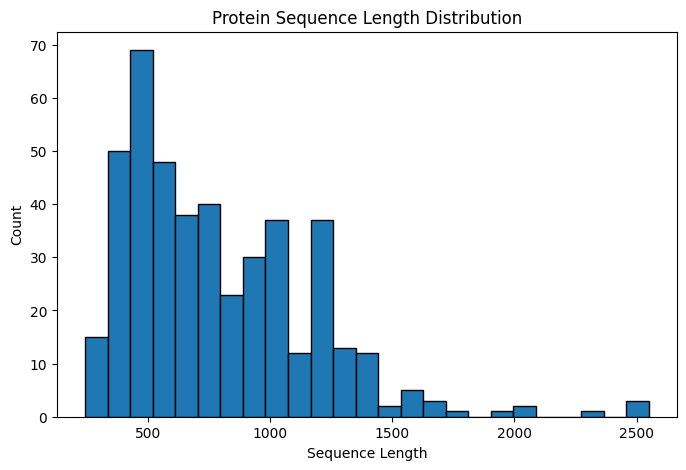

In [39]:
##############################################################
# 6.3 Protein Length Distribution
##############################################################

plt.figure(figsize=(8,5))

plt.hist(
    protein_df["Sequence_Length"],
    bins=25,
    edgecolor="black"
)

plt.xlabel("Sequence Length")
plt.ylabel("Count")
plt.title("Protein Sequence Length Distribution")

plt.show()

In [40]:
##############################################################
# 6.4 Amino Acid Composition
##############################################################

aa_counter = Counter()

for sequence in protein_df["Sequence"]:

    aa_counter.update(sequence)

aa_df = (
    pd.DataFrame(
        {
            "Residue": list(aa_counter.keys()),
            "Count": list(aa_counter.values())
        }
    )
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

display(aa_df)

,Residue,Count
0,L,34482
1,S,27494
2,E,25389
3,G,22297
4,A,22244
5,P,21345
6,K,21302
7,V,20989
8,R,20049
9,D,17489


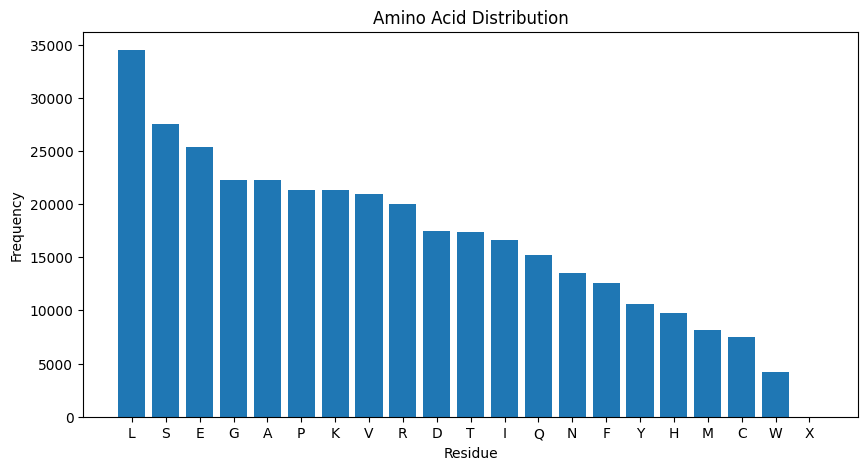

In [41]:
##############################################################
# 6.5 Amino Acid Frequency
##############################################################

plt.figure(figsize=(10,5))

plt.bar(
    aa_df["Residue"],
    aa_df["Count"]
)

plt.xlabel("Residue")
plt.ylabel("Frequency")
plt.title("Amino Acid Distribution")

plt.show()

In [42]:
##############################################################
# 6.6 Sequence Quality Check
##############################################################

standard_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

all_residues = set()

for seq in protein_df["Sequence"]:

    all_residues.update(seq)

print("=" * 60)
print("Residues Present in Dataset")
print("=" * 60)

print(sorted(all_residues))

non_standard = sorted(
    all_residues - standard_amino_acids
)

print()

print("Non-standard Residues")

print(non_standard if non_standard else "None")

Residues Present in Dataset
['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y']

Non-standard Residues
['X']


In [43]:
##############################################################
# 6.7 Proteins Containing X
##############################################################

protein_df["Contains_X"] = protein_df["Sequence"].str.contains("X")

print("=" * 60)
print("Unknown Residues")
print("=" * 60)

print(
    protein_df["Contains_X"].value_counts()
)

display(
    protein_df[
        protein_df["Contains_X"]
    ].head()
)

Unknown Residues
Contains_X
False    441
True       1
Name: count, dtype: int64


,Protein_ID,Sequence,Sequence_Length,Contains_X
406,TESK1,LKMNKLPSNRGNTLREVQLMNRLRHPNILRFMGVCVHQGQLHALTE...,244,True


In [44]:
##############################################################
# 6.8 Length Categories
##############################################################

bins = [0, 250, 500, 750, 1000, 2000]

labels = [

    "0-250",

    "251-500",

    "501-750",

    "751-1000",

    "1000+"

]

protein_df["Length_Group"] = pd.cut(

    protein_df["Sequence_Length"],

    bins=bins,

    labels=labels

)

display(

    protein_df["Length_Group"].value_counts()

)

Length_Group
501-750     122
251-500     116
1000+       109
751-1000     88
0-250         1
Name: count, dtype: int64

In [45]:
##############################################################
# 6.9 Longest and Shortest Proteins
##############################################################

longest = protein_df.loc[
    protein_df["Sequence_Length"].idxmax()
]

shortest = protein_df.loc[
    protein_df["Sequence_Length"].idxmin()
]

print("=" * 60)

print("Longest Protein")

print("=" * 60)

display(longest)

print("=" * 60)

print("Shortest Protein")

print("=" * 60)

display(shortest)

Longest Protein


Protein_ID                                                      MTOR
Sequence           MLGTGPAAATTAATTSSNVSVLQQFASGLKSRNEETRAKAAKELQH...
Sequence_Length                                                 2549
Contains_X                                                     False
Length_Group                                                     NaN
Name: 263, dtype: object

Shortest Protein


Protein_ID                                                     TESK1
Sequence           LKMNKLPSNRGNTLREVQLMNRLRHPNILRFMGVCVHQGQLHALTE...
Sequence_Length                                                  244
Contains_X                                                      True
Length_Group                                                   0-250
Name: 406, dtype: object

In [46]:
##############################################################
# 6.10 Protein Dataset Summary
##############################################################

print("=" * 60)
print("Protein Dataset Summary")
print("=" * 60)

print(f"Total Proteins : {len(protein_df):,}")

print(
    f"Average Length : "
    f"{protein_df['Sequence_Length'].mean():.2f}"
)

print(
    f"Maximum Length : "
    f"{protein_df['Sequence_Length'].max()}"
)

print(
    f"Minimum Length : "
    f"{protein_df['Sequence_Length'].min()}"
)

Protein Dataset Summary
Total Proteins : 442
Average Length : 788.95
Maximum Length : 2549
Minimum Length : 244


# Section 7: Molecular Graph Construction

Graph Neural Networks operate on graph-structured data.

Drug molecules are naturally represented as graphs:

- Atoms become graph nodes.
- Chemical bonds become graph edges.

Each atom is described by a set of node features, while each bond is described by edge features.

The resulting graph is stored as a PyTorch Geometric `Data` object that will later be used by the Graph Neural Network.

In [47]:
##############################################################
# 7.1 Imports
##############################################################

from rdkit import Chem

import torch

from torch_geometric.data import Data

from tqdm.auto import tqdm

In [48]:
##############################################################
# 7.2 Verify RDKit Molecules
##############################################################

print("="*60)
print("Verifying Molecules")
print("="*60)

invalid = drug_df["Molecule"].isnull().sum()

print(f"Invalid Molecules : {invalid}")

assert invalid == 0

print("All molecules are valid.")

Verifying Molecules
Invalid Molecules : 0
All molecules are valid.


In [49]:
##############################################################
# 7.3 Atom Features
##############################################################

def atom_features(atom):

    return [

        atom.GetAtomicNum(),

        atom.GetDegree(),

        atom.GetFormalCharge(),

        atom.GetTotalNumHs(),

        int(atom.GetIsAromatic()),

        atom.GetHybridization().real,

        atom.GetImplicitValence(),

        atom.GetTotalValence(),

        atom.GetMass(),

    ]

In [50]:
##############################################################
# 7.4 Bond Features
##############################################################

def bond_features(bond):

    return [

        bond.GetBondTypeAsDouble(),

        int(bond.GetIsConjugated()),

        int(bond.IsInRing()),

        int(bond.GetStereo())

    ]

In [51]:
##############################################################
# 7.5 Convert Molecule to Graph
##############################################################

def molecule_to_graph(mol):

    node_features = []

    for atom in mol.GetAtoms():

        node_features.append(

            atom_features(atom)

        )

    x = torch.tensor(

        node_features,

        dtype=torch.float

    )

    edge_index = []

    edge_attr = []

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()

        j = bond.GetEndAtomIdx()

        feature = bond_features(bond)

        edge_index.append([i, j])

        edge_index.append([j, i])

        edge_attr.append(feature)

        edge_attr.append(feature)

    edge_index = torch.tensor(

        edge_index,

        dtype=torch.long

    ).t().contiguous()

    edge_attr = torch.tensor(

        edge_attr,

        dtype=torch.float

    )

    return Data(

        x=x,

        edge_index=edge_index,

        edge_attr=edge_attr

    )

In [52]:
##############################################################
# 7.6 Build Graph Dataset
##############################################################

graph_dataset = []

for mol in tqdm(drug_df["Molecule"]):

    graph_dataset.append(

        molecule_to_graph(mol)

    )

print()

print("Graphs Built :", len(graph_dataset))

  0%|          | 0/68 [00:00<?, ?it/s]


Graphs Built : 68


[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[02:29:39] DEPRECATIO

In [53]:
##############################################################
# 7.7 Example Graph
##############################################################

graph = graph_dataset[0]

print(graph)

print()

print("Node Features Shape")

print(graph.x.shape)

print()

print("Edge Index Shape")

print(graph.edge_index.shape)

print()

print("Edge Features Shape")

print(graph.edge_attr.shape)

Data(x=[27, 9], edge_index=[2, 60], edge_attr=[60, 4])

Node Features Shape
torch.Size([27, 9])

Edge Index Shape
torch.Size([2, 60])

Edge Features Shape
torch.Size([60, 4])


In [54]:
##############################################################
# 7.8 Graph Statistics
##############################################################

num_nodes = []

num_edges = []

for graph in graph_dataset:

    num_nodes.append(graph.num_nodes)

    num_edges.append(graph.num_edges)

print("="*60)
print("Graph Dataset Statistics")
print("="*60)

print(f"Average Nodes : {np.mean(num_nodes):.2f}")

print(f"Average Edges : {np.mean(num_edges):.2f}")

print(f"Maximum Nodes : {max(num_nodes)}")

print(f"Maximum Edges : {max(num_edges)}")

Graph Dataset Statistics
Average Nodes : 32.06
Average Edges : 70.88
Maximum Nodes : 46
Maximum Edges : 102


In [55]:
##############################################################
# 7.9 Save Graph Dataset
##############################################################

GRAPH_DIR = PROCESSED_DIR / "graphs"

GRAPH_DIR.mkdir(
    parents=True,
    exist_ok=True
)

torch.save(

    graph_dataset,

    GRAPH_DIR / "drug_graphs.pt"

)

print("Graphs saved successfully.")

Graphs saved successfully.


# Section 8: Advanced Molecular Graph Representation

Drug molecules are represented as graphs where:

- Nodes correspond to atoms.
- Edges correspond to chemical bonds.

Instead of using only numerical atom descriptors, we build a richer representation that captures:

- Atom identity
- Chemical environment
- Aromaticity
- Hybridization
- Chirality
- Ring membership
- Bond characteristics

This representation provides more chemically meaningful input to the Graph Neural Network.

In [56]:
##############################################################
# 8.1 Imports
##############################################################
from rdkit import Chem

from rdkit.Chem.rdchem import HybridizationType
from rdkit.Chem.rdchem import BondType

from torch_geometric.data import Data

import torch
from tqdm.auto import tqdm

In [57]:
##############################################################
# 8.2 Feature Vocabulary
##############################################################

ATOM_LIST = [
    "C",
    "N",
    "O",
    "S",
    "F",
    "P",
    "Cl",
    "Br",
    "I",
    "H",
    "Unknown"
]

HYBRIDIZATION_LIST = [

    HybridizationType.SP,

    HybridizationType.SP2,

    HybridizationType.SP3,

    HybridizationType.SP3D,

    HybridizationType.SP3D2

]

BOND_LIST = [

    BondType.SINGLE,

    BondType.DOUBLE,

    BondType.TRIPLE,

    BondType.AROMATIC

]

In [58]:
##############################################################
# 8.3 Utility
##############################################################

def one_hot(value, choices):

    encoding = [0] * len(choices)

    if value in choices:

        encoding[choices.index(value)] = 1

    return encoding

In [59]:
##############################################################
# 8.4 Atom Features
##############################################################

def atom_features(atom):

    symbol = atom.GetSymbol()

    if symbol not in ATOM_LIST:

        symbol = "Unknown"

    features = []

    features += one_hot(symbol, ATOM_LIST)

    features += one_hot(

        atom.GetHybridization(),

        HYBRIDIZATION_LIST

    )

    features += [

        atom.GetAtomicNum(),

        atom.GetDegree(),

        atom.GetFormalCharge(),

        atom.GetTotalNumHs(),

        atom.GetTotalValence(),

        int(atom.GetIsAromatic()),

        int(atom.IsInRing())

    ]

    return features

In [60]:
##############################################################
# 8.5 Bond Features
##############################################################

def bond_features(bond):

    features = []

    features += one_hot(

        bond.GetBondType(),

        BOND_LIST

    )

    features += [

        int(bond.GetIsConjugated()),

        int(bond.IsInRing())

    ]

    return features

In [61]:
##############################################################
# 8.6 Graph Builder
##############################################################

def build_graph(mol):

    x = []

    edge_index = []

    edge_attr = []

    for atom in mol.GetAtoms():

        x.append(

            atom_features(atom)

        )

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()

        j = bond.GetEndAtomIdx()

        bf = bond_features(bond)

        edge_index.append([i, j])

        edge_index.append([j, i])

        edge_attr.append(bf)

        edge_attr.append(bf)

    x = torch.tensor(

        x,

        dtype=torch.float

    )

    edge_index = torch.tensor(

        edge_index,

        dtype=torch.long

    ).t().contiguous()

    edge_attr = torch.tensor(

        edge_attr,

        dtype=torch.float

    )

    return Data(

        x=x,

        edge_index=edge_index,

        edge_attr=edge_attr

    )

In [62]:
##############################################################
# 8.7 Build Dataset
##############################################################

graph_dataset = []

for mol in tqdm(drug_df["Molecule"]):

    graph_dataset.append(

        build_graph(mol)

    )

print()

print("Graphs Created :", len(graph_dataset))

  0%|          | 0/68 [00:00<?, ?it/s]


Graphs Created : 68


In [63]:
##############################################################
# 8.8 Validation
##############################################################

for i, graph in enumerate(graph_dataset):

    assert graph.x.shape[0] == graph.num_nodes

    assert graph.edge_index.shape[0] == 2

    assert graph.edge_attr.shape[0] == graph.edge_index.shape[1]

print("All graphs validated successfully.")

All graphs validated successfully.


In [64]:
##############################################################
# 8.9 Save Graph Dataset
##############################################################

GRAPH_DIR = PROCESSED_DIR / "graphs"

GRAPH_DIR.mkdir(

    parents=True,

    exist_ok=True

)

torch.save(

    graph_dataset,

    GRAPH_DIR / "drug_graphs.pt"

)

print("Graph dataset saved.")

Graph dataset saved.


# Section 9: Protein Embedding Generation

The protein branch of our model uses a pretrained Protein Language Model (PLM).

Instead of manually engineering biochemical descriptors, we leverage Meta AI's ESM2 model, which has been pretrained on millions of protein sequences.

The workflow is:

1. Tokenize protein sequences.
2. Pass tokens through the frozen ESM2 encoder.
3. Apply mean pooling to obtain a fixed-length embedding.
4. Cache embeddings to disk.
5. Reuse cached embeddings during training.

Since the Davis dataset contains only 442 unique proteins, generating embeddings once is computationally efficient.

In [65]:
##############################################################
# 9.1 Imports
##############################################################

from pathlib import Path

import torch

from transformers import AutoTokenizer
from transformers import EsmModel

from tqdm.auto import tqdm

In [66]:
##############################################################
# 9.2 Configuration
##############################################################

MODEL_NAME = "facebook/esm2_t30_150M_UR50D"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MAX_LENGTH = 1024

BATCH_SIZE = 16

EMBEDDING_DIR = PROCESSED_DIR / "protein_embeddings"

EMBEDDING_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(DEVICE)

cuda


In [67]:
##############################################################
# 9.3 Load ESM2
##############################################################

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = EsmModel.from_pretrained(
    MODEL_NAME
)

model.to(DEVICE)

model.eval()

print("ESM2 loaded successfully.")

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM2 loaded successfully.


In [68]:
##############################################################
# 9.4 Prepare Protein Sequences
##############################################################

protein_sequences = protein_df["Sequence"].tolist()

protein_ids = protein_df["Protein_ID"].tolist()

print("Proteins :", len(protein_sequences))

Proteins : 442


In [69]:
##############################################################
# 9.5 Mean Pooling
##############################################################

def mean_pool(last_hidden_state, attention_mask):

    mask = attention_mask.unsqueeze(-1)

    masked_embeddings = last_hidden_state * mask

    summed = masked_embeddings.sum(dim=1)

    counts = mask.sum(dim=1)

    return summed / counts
    

In [70]:
##############################################################
# 9.6 Generate Embeddings
##############################################################

protein_embeddings = {}

with torch.no_grad():

    for protein_id, sequence in tqdm(
        zip(protein_ids, protein_sequences),
        total=len(protein_sequences)
    ):

        inputs = tokenizer(
            sequence,
            return_tensors="pt",
            truncation=True,
            max_length=MAX_LENGTH
        )

        inputs = {
            key: value.to(DEVICE)
            for key, value in inputs.items()
        }

        outputs = model(**inputs)

        embedding = mean_pool(
            outputs.last_hidden_state,
            inputs["attention_mask"]
        )

        protein_embeddings[protein_id] = (
            embedding.squeeze(0)
            .cpu()
        )

  0%|          | 0/442 [00:00<?, ?it/s]

In [71]:
##############################################################
# 9.7 Save Embeddings
##############################################################

torch.save(

    protein_embeddings,

    EMBEDDING_DIR / "esm2_embeddings.pt"

)

print("Embeddings saved successfully.")

Embeddings saved successfully.


In [72]:
##############################################################
# 9.8 Verification
##############################################################

sample_id = protein_ids[0]

embedding = protein_embeddings[sample_id]

print("=" * 60)
print("Embedding Verification")
print("=" * 60)

print("Protein ID :", sample_id)

print("Embedding Shape :", embedding.shape)

Embedding Verification
Protein ID : AAK1
Embedding Shape : torch.Size([640])


In [73]:
##############################################################
# 9.9 Reload Test
##############################################################

loaded_embeddings = torch.load(
    EMBEDDING_DIR / "esm2_embeddings.pt"
)

print("Loaded :", len(loaded_embeddings))

Loaded : 442


# Section 10: Interaction Dataset

Our model predicts the interaction between a drug and a protein.

Each training example consists of:

- Drug molecular graph
- Protein embedding
- Binding affinity value

The Davis dataset contains:

- 68 drugs
- 442 proteins

forming approximately 30,000 drug–protein interaction pairs.

This section constructs a dataset where every sample combines these three components.

In [74]:
##############################################################
# 10.1 Imports
##############################################################

import pickle

import numpy as np

import torch

from torch.utils.data import Dataset

In [75]:
##############################################################
# 10.2 Load Processed Objects
##############################################################

graph_dataset = torch.load(
    GRAPH_DIR / "drug_graphs.pt",
    weights_only=False
)

protein_embeddings = torch.load(
    EMBEDDING_DIR / "esm2_embeddings.pt"
)

print("Drug Graphs :", len(graph_dataset))
print("Protein Embeddings :", len(protein_embeddings))

Drug Graphs : 68
Protein Embeddings : 442


In [76]:
##############################################################
# 10.3 Affinity Matrix
##############################################################

with open(
    DATASET_ROOT / "Y",
    "rb"
) as f:

    affinity_matrix = pickle.load(
        f,
        encoding="latin1"
    )

affinity_matrix = np.array(
    affinity_matrix
)

print(affinity_matrix.shape)

(68, 442)


In [77]:
##############################################################
# Convert Kd (nM) -> pKd
##############################################################

affinity_matrix = -np.log10(affinity_matrix / 1e9).astype(np.float32)

print("Affinity range after conversion:")
print(affinity_matrix.min(), affinity_matrix.max())

Affinity range after conversion:
5.0 10.79588


In [78]:
##############################################################
# 10.4 Protein Mapping
##############################################################

protein_ids = list(
    protein_embeddings.keys()
)

protein_index = {

    idx: pid

    for idx, pid

    in enumerate(protein_ids)

}

In [79]:
##############################################################
# 10.5 Dataset
##############################################################

class DTIDataset(Dataset):

    def __init__(

        self,

        drug_graphs,

        protein_embeddings,

        affinity_matrix

    ):

        self.samples = []

        for drug_idx in range(

            affinity_matrix.shape[0]

        ):

            for protein_idx in range(

                affinity_matrix.shape[1]

            ):

                affinity = affinity_matrix[

                    drug_idx,

                    protein_idx

                ]

                self.samples.append(

                    (

                        drug_idx,

                        protein_idx,

                        affinity

                    )

                )

        self.drug_graphs = drug_graphs

        self.protein_embeddings = protein_embeddings

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        drug_idx, protein_idx, affinity = self.samples[idx]

        graph = self.drug_graphs[drug_idx]

        protein = self.protein_embeddings[
            protein_index[protein_idx]
        ]

        return {

            "graph": graph,

            "protein": protein.float(),

            "label": torch.tensor(
                affinity,
                dtype=torch.float
            )

        }

In [80]:
##############################################################
# 10.6 Build Dataset
##############################################################

dataset = DTIDataset(

    graph_dataset,

    protein_embeddings,

    affinity_matrix

)

print("Samples :", len(dataset))

Samples : 30056


In [81]:
##############################################################
# 10.7 Example
##############################################################

sample = dataset[0]

print(sample["graph"])

print()

print(sample["protein"].shape)

print()

print(sample["label"])

Data(x=[27, 23], edge_index=[2, 60], edge_attr=[60, 6])

torch.Size([640])

tensor(7.3665)


In [82]:
##############################################################
# 10.8 Statistics
##############################################################

labels = np.array(

    [

        sample[2]

        for sample in dataset.samples

    ]

)

print("="*60)

print("Interaction Dataset Statistics")

print("="*60)

print(f"Samples : {len(labels):,}")

print(f"Mean Affinity : {labels.mean():.3f}")

print(f"Std : {labels.std():.3f}")

print(f"Minimum : {labels.min():.3f}")

print(f"Maximum : {labels.max():.3f}")

Interaction Dataset Statistics
Samples : 30,056
Mean Affinity : 5.452
Std : 0.895
Minimum : 5.000
Maximum : 10.796


# Section 11: Official Train/Test Split

The Davis benchmark provides predefined train and test folds.

Instead of randomly splitting the interaction matrix, we use these official folds to ensure our results are directly comparable with published Drug–Target Interaction models.

Each interaction pair is assigned to either:

- Training
- Validation
- Testing

using the benchmark protocol.

In [83]:
##############################################################
# 11.1 Imports
##############################################################

from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset

In [84]:
train_file = DATASET_ROOT / "folds/train_fold_setting1.txt"

with open(train_file, "r") as f:
    print(f.read(200))

[[1483, 18097, 11736, 16204, 2085, 2144, 943, 18735, 10666, 2157, 12561, 20525, 19925, 7777, 20559, 21935, 4774, 10742, 5030, 9424, 21135, 7336, 3556, 16633, 29640, 15363, 24722, 29131, 27290, 16090, 


In [85]:
##############################################################
# 11.2 Load Official Folds
##############################################################

import json

with open(DATASET_ROOT / "folds/train_fold_setting1.txt", "r") as f:
    train_folds = json.load(f)

with open(DATASET_ROOT / "folds/test_fold_setting1.txt", "r") as f:
    test_fold = json.load(f)

print("Training folds :", len(train_folds))
print("Test samples   :", len(test_fold))

Training folds : 5
Test samples   : 5010


In [86]:
##############################################################
# 11.3 Validation Fold
##############################################################

VALIDATION_FOLD = 0

validation_indices = train_folds[VALIDATION_FOLD]

training_indices = []

for i, fold in enumerate(train_folds):

    if i != VALIDATION_FOLD:

        training_indices.extend(fold)

print(len(training_indices))

print(len(validation_indices))

20036
5010


In [87]:
##############################################################
# 11.4 Index Conversion
##############################################################

num_drugs = affinity_matrix.shape[0]

num_proteins = affinity_matrix.shape[1]

def flat_to_pair(index):
    drug_idx = index // num_proteins
    protein_idx = index % num_proteins
    return drug_idx, protein_idx

# Debugging

In [88]:
print("=" * 60)
print("Affinity before dataset creation")
print("=" * 60)

print(id(affinity_matrix))
print(affinity_matrix.min(), affinity_matrix.max())

Affinity before dataset creation
137941401498416
5.0 10.79588


In [89]:
##############################################################
# 11.5 Dataset
##############################################################

class FoldDataset(Dataset):

    def __init__(

        self,

        indices,

        graphs,

        protein_embeddings,

        affinity_matrix

    ):

        self.indices = indices

        self.graphs = graphs

        self.embeddings = protein_embeddings

        self.affinity = affinity_matrix

        self.protein_keys = list(

            protein_embeddings.keys()

        )

    def __len__(self):

        return len(self.indices)

    def __getitem__(self, idx):

        flat_index = self.indices[idx]

        drug_idx, protein_idx = flat_to_pair(

            flat_index

        )

        graph = self.graphs[drug_idx]

        protein = self.embeddings[
            self.protein_keys[protein_idx]
        ]

        label = torch.tensor(

            self.affinity[
                drug_idx,
                protein_idx
            ],

            dtype=torch.float

        )

        return {

            "graph": graph,

            "protein": protein,

            "label": label

        }

In [90]:
##############################################################
# 11.6 Create Datasets
##############################################################

train_dataset = FoldDataset(
    training_indices,
    graph_dataset,
    protein_embeddings,
    affinity_matrix
)

valid_dataset = FoldDataset(
    validation_indices,
    graph_dataset,
    protein_embeddings,
    affinity_matrix
)

test_dataset = FoldDataset(
    test_fold,
    graph_dataset,
    protein_embeddings,
    affinity_matrix
)

print()

print("Train :", len(train_dataset))

print("Valid :", len(valid_dataset))

print("Test  :", len(test_dataset))


Train : 20036
Valid : 5010
Test  : 5010


In [91]:
print("=" * 60)
print("Dataset after creation")
print("=" * 60)

print(id(train_dataset.affinity))
print(train_dataset.affinity.min(), train_dataset.affinity.max())

Dataset after creation
137941401498416
5.0 10.79588


In [92]:
##############################################################
# 11.7 Verification
##############################################################

sample = train_dataset[0]

print(sample["graph"])

print(sample["protein"].shape)

print(sample["label"])

Data(x=[19, 23], edge_index=[2, 42], edge_attr=[42, 6])
torch.Size([640])
tensor(5.)


In [93]:
##############################################################
# 11.8 Statistics
##############################################################

print("="*60)

print("Fold Dataset")

print("="*60)

print(f"Train : {len(train_dataset):,}")

print(f"Valid : {len(valid_dataset):,}")

print(f"Test  : {len(test_dataset):,}")

Fold Dataset
Train : 20,036
Valid : 5,010
Test  : 5,010


Graph Dataset
        +
        
Protein Embeddings
        +
        
Affinity Labels
        │
        ▼
        
Custom Collate Function
        │
        ▼
        
PyTorch Geometric Batch
        │
        ▼

        
Training Loop

# Debugging


# Section 12: DataLoader Pipeline

The dataset contains three different data modalities:

- Molecular graphs
- Protein embeddings
- Binding affinity labels

Unlike conventional datasets, molecular graphs have different numbers of atoms and bonds.

PyTorch Geometric provides a specialized `DataLoader` that merges multiple graphs into one disconnected graph while preserving graph boundaries.

This section prepares efficient mini-batches for training.

In [94]:
##############################################################
# 12.1 Imports
##############################################################

import torch

from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch

In [95]:
##############################################################
# 12.2 Custom Collate Function
##############################################################

def collate_fn(batch):

    graphs = [sample["graph"] for sample in batch]

    graphs = Batch.from_data_list(graphs)

    proteins = torch.stack(

        [

            sample["protein"]

            for sample in batch

        ]

    )

    labels = torch.stack(

        [

            sample["label"]

            for sample in batch

        ]

    )

    return {

        "graph": graphs,

        "protein": proteins,

        "label": labels

    }

In [96]:
##############################################################
# 12.3 Configuration
##############################################################

BATCH_SIZE = 64

NUM_WORKERS = 2

PIN_MEMORY = True

In [97]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [98]:
print(train_dataset.affinity.min(), train_dataset.affinity.max())

batch = next(iter(train_loader))
print(batch["label"][:10])

5.0 10.79588
tensor([5.0000, 7.2676, 5.0000, 5.0000, 5.2757, 5.0000, 5.1805, 5.0000, 5.0000,
        8.5086])


In [99]:
##############################################################
# 12.5 Verify Batch
##############################################################

batch = next(iter(train_loader))

print("=" * 60)
print("Batch Verification")
print("=" * 60)

print(batch["graph"])
print()

print("Protein Shape")
print(batch["protein"].shape)

print()

print("Label Shape")
print(batch["label"].shape)

Batch Verification
DataBatch(x=[2007, 23], edge_index=[2, 4426], edge_attr=[4426, 6], batch=[2007], ptr=[65])

Protein Shape
torch.Size([64, 640])

Label Shape
torch.Size([64])


In [100]:
##############################################################
# 12.6 Graph Batch Information
##############################################################

graph_batch = batch["graph"]

print("Number of graphs :", graph_batch.num_graphs)
print("Total nodes      :", graph_batch.num_nodes)
print("Total edges      :", graph_batch.num_edges)

Number of graphs : 64
Total nodes      : 2007
Total edges      : 4426


In [101]:
##############################################################
# 12.7 Device Test
##############################################################

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

graph = batch["graph"].to(DEVICE)

protein = batch["protein"].to(DEVICE)

label = batch["label"].to(DEVICE)

print("Device transfer successful!")

Device transfer successful!


In [102]:
##############################################################
# 12.8 DataLoader Benchmark
##############################################################

import time

start = time.time()

for i, batch in enumerate(train_loader):

    if i == 10:

        break

elapsed = time.time() - start

print(f"Time for 10 batches: {elapsed:.2f} seconds")

Time for 10 batches: 0.03 seconds


# Section 13: Drug Graph Encoder

This section implements the Graph Neural Network used to encode molecular graphs.

The encoder receives:

- Node features
- Edge indices
- Edge features

and produces a fixed-length embedding representing the entire drug molecule.

We use GINEConv because it naturally incorporates bond features during message passing, making it well suited for molecular graphs.

In [103]:
##############################################################
# 13.1 Imports
##############################################################

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import (
    GINEConv,
    global_mean_pool,
    BatchNorm
)

In [104]:
##############################################################
# 13.2 Configuration
##############################################################

NODE_DIM = graph_dataset[0].x.shape[1]

EDGE_DIM = graph_dataset[0].edge_attr.shape[1]

HIDDEN_DIM = 128

NUM_GNN_LAYERS = 3

DROPOUT = 0.2

In [105]:
##############################################################
# 13.3 MLP Builder
##############################################################

def build_mlp(hidden_dim):
    return nn.Sequential(
        nn.Linear(hidden_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(inplace=True),

        nn.Linear(hidden_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(inplace=True),

        nn.Linear(hidden_dim, hidden_dim)
    )

In [106]:
##############################################################
# 13.4 Drug Encoder
##############################################################

class DrugEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.node_projection = nn.Linear(
            NODE_DIM,
            HIDDEN_DIM
        )

        self.edge_projection = nn.Linear(
            EDGE_DIM,
            HIDDEN_DIM
        )

        self.convs = nn.ModuleList()

        self.norms = nn.ModuleList()

        for _ in range(NUM_GNN_LAYERS):

            self.convs.append(

                GINEConv(
                    nn=build_mlp(HIDDEN_DIM),
                    edge_dim=HIDDEN_DIM
                )

            )

            self.norms.append(

                BatchNorm(HIDDEN_DIM)

            )

        self.dropout = nn.Dropout(DROPOUT)

    def forward(
        self,
        graph
    ):

        x = self.node_projection(graph.x)

        edge_attr = self.edge_projection(
            graph.edge_attr
        )

        for conv, norm in zip(
            self.convs,
            self.norms
        ):

            x = conv(
                x,
                graph.edge_index,
                edge_attr
            )

            x = norm(x)

            x = F.relu(x)

            x = self.dropout(x)

        x = global_mean_pool(
            x,
            graph.batch
        )

        return x

In [107]:
##############################################################
# 13.5 Verification
##############################################################

encoder = DrugEncoder().to(DEVICE)

batch = next(iter(train_loader))

graph = batch["graph"].to(DEVICE)

with torch.no_grad():

    embedding = encoder(graph)

print("=" * 60)

print("Drug Embedding Shape")

print("=" * 60)

print(embedding.shape)

Drug Embedding Shape
torch.Size([64, 128])


In [108]:
##############################################################
# 13.6 Model Size
##############################################################

params = sum(

    p.numel()

    for p in encoder.parameters()

)

trainable = sum(

    p.numel()

    for p in encoder.parameters()

    if p.requires_grad

)

print("=" * 60)

print("Drug Encoder")

print("=" * 60)

print(f"Parameters : {params:,}")

print(f"Trainable : {trainable:,}")

Drug Encoder
Parameters : 204,416
Trainable : 204,416


In [109]:
##############################################################
# 13.7 Benchmark
##############################################################

import time

encoder.eval()

batch = next(iter(train_loader))

graph = batch["graph"].to(DEVICE)

start = time.time()

with torch.no_grad():

    for _ in range(100):

        encoder(graph)

elapsed = time.time() - start

print(f"Average forward time: {elapsed/100:.4f} sec")

Average forward time: 0.0022 sec


# Section 14: Drug–Protein Fusion Network

The complete model combines information from both modalities:

- Drug molecular graph embeddings from the GINE encoder.
- Protein embeddings generated by the pretrained ESM2 model.

Before fusion, each modality is projected into a shared latent space.

The projected embeddings are concatenated and passed through a multilayer perceptron to predict the binding affinity.

In [110]:
##############################################################
# 14.1 Imports
##############################################################

import torch
import torch.nn as nn
import torch.nn.functional as F

In [111]:
##############################################################
# 14.2 Model Configuration
##############################################################

PROTEIN_DIM = 640

DRUG_DIM = 128

FUSION_DIM = 256

MLP_HIDDEN = 512

DROPOUT = 0.3

In [112]:
##############################################################
# 14.3 Drug Target Interaction Model
##############################################################

class DTIModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.drug_encoder = DrugEncoder()

        ########################################################
        # Drug Projection
        ########################################################

        self.drug_projection = nn.Sequential(

            nn.Linear(DRUG_DIM, FUSION_DIM),

            nn.BatchNorm1d(FUSION_DIM),

            nn.SiLU(),

            nn.Dropout(DROPOUT)

        )

        ########################################################
        # Protein Projection
        ########################################################

        self.protein_projection = nn.Sequential(

            nn.Linear(PROTEIN_DIM, FUSION_DIM),

            nn.BatchNorm1d(FUSION_DIM),

            nn.SiLU(),

            nn.Dropout(DROPOUT)

        )

        ########################################################
        # Fusion Network
        ########################################################

        self.fusion = nn.Sequential(

            nn.Linear(FUSION_DIM * 4, MLP_HIDDEN),

            nn.BatchNorm1d(MLP_HIDDEN),

            nn.SiLU(),

            nn.Dropout(DROPOUT),

            nn.Linear(MLP_HIDDEN, 512),

            nn.BatchNorm1d(512),

            nn.SiLU(),

            nn.Dropout(DROPOUT),

            nn.Linear(512, 256),

            nn.BatchNorm1d(256),

            nn.SiLU(),

            nn.Dropout(DROPOUT),

            nn.Linear(256, 1)

        )

    def forward(
        self,
        graph,
        protein
    ):

        ########################################################
        # Drug Encoder
        ########################################################

        drug_embedding = self.drug_encoder(graph)

        drug_embedding = self.drug_projection(
            drug_embedding
        )

        ########################################################
        # Protein Encoder
        ########################################################

        protein_embedding = self.protein_projection(
            protein
        )

        ########################################################
        # Pairwise Interaction Features
        ########################################################

        interaction = drug_embedding * protein_embedding

        difference = torch.abs(
            drug_embedding - protein_embedding
        )

        ########################################################
        # Fusion
        ########################################################

        fusion = torch.cat(
            [
                drug_embedding,
                protein_embedding,
                interaction,
                difference
            ],
            dim=1
        )

        ########################################################
        # Prediction
        ########################################################

        output = self.fusion(fusion)

        return output.squeeze(1)

In [113]:
batch = next(iter(train_loader))

graph = batch["graph"].to(device)
protein = batch["protein"].to(device)

model = DTIModel().to(device)

with torch.no_grad():

    drug = model.drug_projection(model.drug_encoder(graph))

    prot = model.protein_projection(protein)

    interaction = drug * prot

    difference = torch.abs(drug - prot)

    fusion = torch.cat(
        [drug, prot, interaction, difference],
        dim=1
    )

print("Drug       :", drug.shape)
print("Protein    :", prot.shape)
print("Interaction:", interaction.shape)
print("Difference :", difference.shape)
print("Fusion     :", fusion.shape)
print("Expected   :", model.fusion[0].in_features)

Drug       : torch.Size([64, 256])
Protein    : torch.Size([64, 256])
Interaction: torch.Size([64, 256])
Difference : torch.Size([64, 256])
Fusion     : torch.Size([64, 1024])
Expected   : 1024


In [114]:
batch = next(iter(train_loader))

graph = batch["graph"].to(device)
protein = batch["protein"].to(device)

with torch.no_grad():
    pred = model(graph, protein)

In [115]:
##############################################################
# 14.4 Initialize Model
##############################################################

model = DTIModel().to(DEVICE)

print(model)

DTIModel(
  (drug_encoder): DrugEncoder(
    (node_projection): Linear(in_features=23, out_features=128, bias=True)
    (edge_projection): Linear(in_features=6, out_features=128, bias=True)
    (convs): ModuleList(
      (0-2): 3 x GINEConv(nn=Sequential(
        (0): Linear(in_features=128, out_features=128, bias=True)
        (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Linear(in_features=128, out_features=128, bias=True)
        (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): Linear(in_features=128, out_features=128, bias=True)
      ))
    )
    (norms): ModuleList(
      (0-2): 3 x BatchNorm(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (drug_projection): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1):

In [116]:
##############################################################
# 14.5 Forward Test
##############################################################

batch = next(iter(train_loader))

graph = batch["graph"].to(DEVICE)

protein = batch["protein"].to(DEVICE)

with torch.no_grad():

    prediction = model(

        graph,

        protein

    )

print("=" * 60)

print("Prediction Shape")

print("=" * 60)

print(prediction.shape)

Prediction Shape
torch.Size([64])


In [117]:
##############################################################
# 14.6 Model Parameters
##############################################################

total = sum(

    p.numel()

    for p in model.parameters()

)

trainable = sum(

    p.numel()

    for p in model.parameters()

    if p.requires_grad

)

print("=" * 60)

print("Model Statistics")

print("=" * 60)

print(f"Total Parameters      : {total:,}")

print(f"Trainable Parameters  : {trainable:,}")

Model Statistics
Total Parameters      : 1,324,161
Trainable Parameters  : 1,324,161


In [118]:
##############################################################
# 14.7 Model Summary
##############################################################

print("=" * 60)

print("Input")

print("=" * 60)

print("Drug Graph")

print("Protein Embedding : (640,)")

print()

print("=" * 60)

print("Output")

print("=" * 60)

print("Binding Affinity")

Input
Drug Graph
Protein Embedding : (640,)

Output
Binding Affinity


# Section 15: Training Utilities

This section prepares all components required for model training.

It includes:

- Loss function
- Optimizer
- Learning rate scheduler
- Metric tracking
- Checkpoint saving
- Automatic resume capability

These utilities make the training process reproducible and robust against interruptions.

In [119]:
##############################################################
# 15.1 Imports
##############################################################

from pathlib import Path
import json

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [120]:
##############################################################
# 15.2 Training Configuration
##############################################################

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

NUM_EPOCHS = 50

CHECKPOINT_DIR = Path("checkpoints")

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [121]:
##############################################################
# 15.3 Loss
##############################################################

criterion = nn.MSELoss()

In [122]:
##############################################################
# 15.4 Optimizer
##############################################################

optimizer = AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY

)

In [123]:
##############################################################
# 15.5 Scheduler
##############################################################

scheduler = ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=3,

    min_lr=1e-6
)

In [124]:
##############################################################
# 15.6 Metric History
##############################################################

history = {

    "train_loss": [],

    "valid_loss": [],

    "learning_rate": []

}

In [125]:
##############################################################
# 15.7 Save Checkpoint
##############################################################

def save_checkpoint(

    epoch,

    model,

    optimizer,

    scheduler,

    history,

    best_loss,

    filename

):

    checkpoint = {

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "scheduler_state_dict": scheduler.state_dict(),

        "history": history,

        "best_loss": best_loss

    }

    torch.save(

        checkpoint,

        CHECKPOINT_DIR / filename

    )

In [126]:
##############################################################
# 15.8 Load Checkpoint
##############################################################

def load_checkpoint(

    filename,

    model,

    optimizer,

    scheduler

):

    checkpoint = torch.load(

        CHECKPOINT_DIR / filename,

        map_location=DEVICE
    )

    model.load_state_dict(

        checkpoint["model_state_dict"]

    )

    optimizer.load_state_dict(

        checkpoint["optimizer_state_dict"]

    )

    scheduler.load_state_dict(

        checkpoint["scheduler_state_dict"]

    )

    return (

        checkpoint["epoch"],

        checkpoint["history"],

        checkpoint["best_loss"]

    )

In [127]:
##############################################################
# 15.9 Save Best Model
##############################################################

def save_best_model(

    model

):

    torch.save(

        model.state_dict(),

        CHECKPOINT_DIR / "best_model.pt"

    )

In [128]:
##############################################################
# 15.10 Save History
##############################################################

def save_history(history):

    with open(

        CHECKPOINT_DIR / "history.json",

        "w"

    ) as f:

        json.dump(

            history,

            f,

            indent=4
        )

In [129]:
##############################################################
# 15.11 Resume
##############################################################

start_epoch = 0
best_loss = float("inf")
history = {
    "train_loss": [],
    "val_loss": [],
    "train_rmse": [],
    "val_rmse": [],
    "learning_rate": []
}

print("Training from scratch.")

Training from scratch.


In [130]:
##############################################################
# 15.12 Verification
##############################################################

print("="*60)

print("Training Utilities Ready")

print("="*60)

print("Loss :", criterion)

print()

print("Optimizer")

print(optimizer)

print()

print("Scheduler")

print(scheduler)

print()

print("Checkpoint Directory")

print(CHECKPOINT_DIR)

Training Utilities Ready
Loss : MSELoss()

Optimizer
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)

Scheduler

Checkpoint Directory
checkpoints


# Section 16: Model Training

This section trains the Drug–Target Interaction model.

The training pipeline consists of:

- Mixed precision training (AMP)
- Gradient clipping
- Learning rate scheduling
- Checkpoint saving
- Validation after every epoch
- Automatic resume
- Early stopping

The model is optimized using Mean Squared Error (MSE) loss.

In [131]:
##############################################################
# 16.1 Imports
##############################################################

from tqdm.auto import tqdm

import torch

from torch.amp import autocast
from torch.amp import GradScaler

from sklearn.metrics import mean_squared_error

In [132]:
##############################################################
# 16.2 AMP
##############################################################

scaler = GradScaler(
    device="cuda",
    enabled=torch.cuda.is_available()
)

In [133]:
##############################################################
# 16.3 Training Function
##############################################################

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    progress = tqdm(
        loader,
        leave=False
    )

    for batch in progress:

        graph = batch["graph"].to(device)

        protein = batch["protein"].to(device)

        label = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=device.type,
            enabled=torch.cuda.is_available()
        ):

            prediction = model(
                graph,
                protein
            )
            

            loss = criterion(
                prediction,
                label
            )

        scaler.scale(loss).backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return running_loss / len(loader)

In [134]:
##############################################################
# 16.4 Validation
##############################################################

def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0

    predictions = []

    targets = []

    with torch.no_grad():

        for batch in tqdm(
            loader,
            leave=False
        ):

            graph = batch["graph"].to(device)

            protein = batch["protein"].to(device)

            label = batch["label"].to(device)

            prediction = model(
                graph,
                protein
            )

            loss = criterion(
                prediction,
                label
            )

            running_loss += loss.item()

            predictions.extend(
                prediction.cpu().numpy()
            )

            targets.extend(
                label.cpu().numpy()
            )

    mse = mean_squared_error(
        targets,
        predictions
    )

    return (

        running_loss / len(loader),

        mse

    )

In [135]:
##############################################################
# 16.5 Early Stopping
##############################################################

class EarlyStopping:

    def __init__(
        self,
        patience=10
    ):

        self.patience = patience

        self.best = float("inf")

        self.counter = 0

    def step(
        self,
        loss
    ):

        if loss < self.best:

            self.best = loss

            self.counter = 0

            return False

        self.counter += 1

        return self.counter >= self.patience

In [136]:
##############################################################
# 16.6 Initialize
##############################################################

early_stopping = EarlyStopping(
    patience=7
)

In [137]:
##############################################################
# 16.7 Main Training Loop
##############################################################
for epoch in range(
    start_epoch,
    NUM_EPOCHS
):

    print()

    print("="*70)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}"
    )

    print("="*70)

    train_loss = train_one_epoch(

        model,

        train_loader,

        optimizer,

        criterion,

        scaler,

        DEVICE

    )

    valid_loss, mse = validate_one_epoch(

        model,

        valid_loader,

        criterion,

        DEVICE

    )

    scheduler.step(
        valid_loss
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        valid_loss
    )

    history["learning_rate"].append(

        optimizer.param_groups[0]["lr"]

    )

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Valid Loss : {valid_loss:.4f}"
    )

    print(
        f"MSE : {mse:.4f}"
    )

    if valid_loss < best_loss:

        best_loss = valid_loss

        save_best_model(model)

    save_checkpoint(

        epoch,

        model,

        optimizer,

        scheduler,

        history,

        best_loss,

        "latest.pt"

    )

    save_history(history)

    if early_stopping.step(
        valid_loss
    ):

        print()

        print("Early stopping triggered.")

        break


Epoch 1/50


  0%|          | 0/314 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 4.6290
Valid Loss : 0.7458
MSE : 0.7463

Epoch 2/50


  0%|          | 0/314 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.3210
Valid Loss : 0.2842
MSE : 0.2840

Epoch 50/50


  0%|          | 0/314 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Train Loss : 0.3295
Valid Loss : 0.2890
MSE : 0.2889


In [138]:
print(history)

{'train_loss': [4.6289713166321915, 1.0050963894197136, 0.8593444504365799, 0.7457162905365798, 0.697448103860685, 0.6511350294966607, 0.6068735523208691, 0.573582105006382, 0.5463822094403255, 0.5399169725407461, 0.5260035236170337, 0.568071576630234, 0.5382116764404212, 0.506253946691182, 0.49112621860898986, 0.44654043222878387, 0.42874418891918886, 0.4304179203738073, 0.41812364657403556, 0.4006347514356777, 0.39381196326131274, 0.39559667049699526, 0.3940055076104061, 0.3823487895309545, 0.36876095295142214, 0.3728605589953957, 0.37885429449142166, 0.3760632547982939, 0.38372626573227014, 0.3778534685825087, 0.36670008681382343, 0.36357856707967773, 0.356299089872913, 0.34606255586170087, 0.3449891490541446, 0.34422353650354276, 0.33750080670805493, 0.33155068612782057, 0.3294094333033653, 0.331867258592396, 0.345281034755479, 0.3290937309194902, 0.32860771656795673, 0.32556397012274735, 0.3216719638769794, 0.323583246440075, 0.32429907622800513, 0.32490778572050627, 0.32099751001

In [139]:
print("start_epoch =", start_epoch)
print("NUM_EPOCHS  =", NUM_EPOCHS)

start_epoch = 0
NUM_EPOCHS  = 50


In [140]:
batch = next(iter(train_loader))

print(batch.keys())
print(batch["label"][:10])

print("Min label:", batch["label"].min().item())
print("Max label:", batch["label"].max().item())

dict_keys(['graph', 'protein', 'label'])
tensor([6.5229, 5.0000, 6.3872, 5.0000, 5.0000, 5.0000, 5.0000, 7.1549, 5.0000,
        5.0000])
Min label: 5.0
Max label: 9.346787452697754


In [141]:
import numpy as np

labels = []

for batch in train_loader:
    labels.extend(batch["label"].cpu().numpy())

labels = np.array(labels)

print("Unique largest values:")
print(np.unique(labels)[-20:])

print("Number of 10000 labels:", np.sum(labels == 10000))
print("Total labels:", len(labels))

Unique largest values:
[ 9.853872  9.886057  9.920818  9.958608 10.       10.031517 10.065501
 10.124939 10.19382  10.207608 10.236572 10.327902 10.337242 10.387217
 10.408936 10.431798 10.443698 10.537602 10.721247 10.79588 ]
Number of 10000 labels: 0
Total labels: 20036


# Section 17: Model Evaluation

This section evaluates the trained Drug–Target Interaction model on the official Davis test set.

We compute several standard regression metrics used in the literature:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Pearson Correlation
- R² Score
- Concordance Index (CI)

We also generate diagnostic plots to visualize model performance.

In [142]:
##############################################################
# 17.1 Imports
##############################################################

import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import pearsonr

In [143]:
##############################################################
# 17.2 Prediction Function
##############################################################

def predict_dataset(
    model,
    loader,
    device
):

    model.eval()

    predictions = []

    targets = []

    with torch.no_grad():

        for batch in tqdm(loader):

            graph = batch["graph"].to(device)

            protein = batch["protein"].to(device)

            label = batch["label"].to(device)

            prediction = model(
                graph,
                protein
            )

            predictions.extend(
                prediction.cpu().numpy()
            )

            targets.extend(
                label.cpu().numpy()
            )

    predictions = np.array(predictions)

    targets = np.array(targets)

    return predictions, targets

In [144]:
##############################################################
# 17.3 Concordance Index
##############################################################

def concordance_index(
    y_true,
    y_pred
):

    concordant = 0

    permissible = 0

    n = len(y_true)

    for i in range(n):

        for j in range(i + 1, n):

            if y_true[i] == y_true[j]:
                continue

            permissible += 1

            if (
                (y_pred[i] > y_pred[j])
                ==
                (y_true[i] > y_true[j])
            ):

                concordant += 1

            elif y_pred[i] == y_pred[j]:

                concordant += 0.5

    return concordant / permissible

In [145]:
##############################################################
# 17.4 Test Prediction
##############################################################

predictions, targets = predict_dataset(

    model,

    test_loader,

    DEVICE

)

print("Prediction completed.")

  0%|          | 0/79 [00:00<?, ?it/s]

Prediction completed.


In [146]:
##############################################################
# 17.5 Metrics
##############################################################

mse = mean_squared_error(
    targets,
    predictions
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    targets,
    predictions
)

r2 = r2_score(
    targets,
    predictions
)

pearson = pearsonr(
    targets,
    predictions
)[0]

ci = concordance_index(
    targets,
    predictions
)

print("=" * 60)
print("Test Metrics")
print("=" * 60)

print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"R²       : {r2:.4f}")
print(f"Pearson  : {pearson:.4f}")
print(f"CI       : {ci:.4f}")

Test Metrics
MSE      : 0.3114
RMSE     : 0.5580
MAE      : 0.3112
R²       : 0.6115
Pearson  : 0.7882
CI       : 0.8657


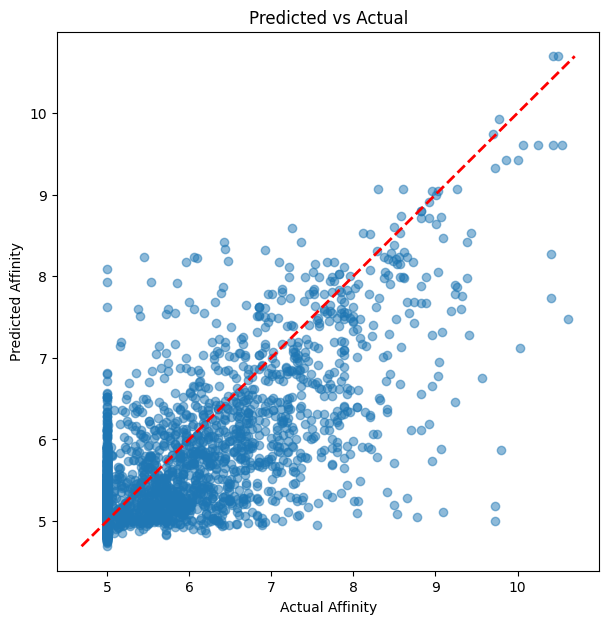

In [147]:
##############################################################
# 17.6 Scatter Plot
##############################################################

plt.figure(figsize=(7,7))

plt.scatter(
    targets,
    predictions,
    alpha=0.5
)

low = min(targets.min(), predictions.min())
high = max(targets.max(), predictions.max())

plt.plot(
    [low, high],
    [low, high],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Affinity")
plt.ylabel("Predicted Affinity")
plt.title("Predicted vs Actual")

plt.show()

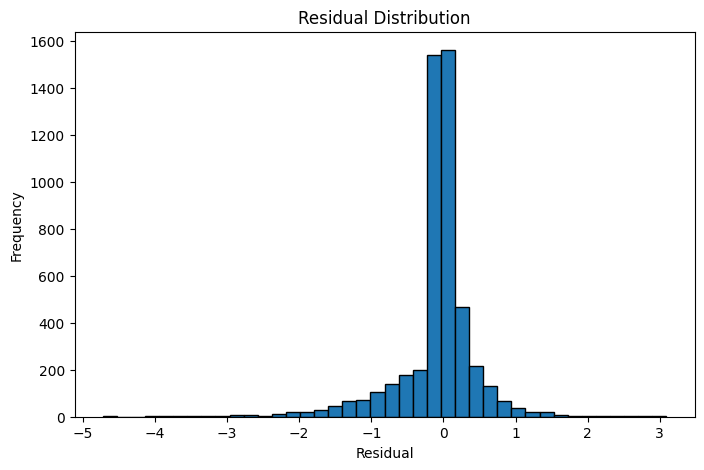

In [148]:
##############################################################
# 17.7 Residuals
##############################################################

residuals = predictions - targets

plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

In [149]:
##############################################################
# 17.8 Save Results
##############################################################

results = {

    "MSE": float(mse),

    "RMSE": float(rmse),

    "MAE": float(mae),

    "R2": float(r2),

    "Pearson": float(pearson),

    "CI": float(ci)

}

with open(

    CHECKPOINT_DIR / "test_results.json",

    "w"

) as f:

    json.dump(

        results,

        f,

        indent=4

    )

print("Evaluation results saved.")

Evaluation results saved.


# Section 18: Inference Pipeline

This section demonstrates how to use the trained Drug–Target Interaction model to predict the binding affinity of a completely new drug–protein pair.

The inference pipeline performs:

1. SMILES → Molecular Graph
2. Protein Sequence → ESM2 Embedding
3. Graph + Embedding → DTI Model
4. Predicted Binding Affinity

In [150]:
##############################################################
# 18.1 Load Best Model
##############################################################

model = DTIModel().to(DEVICE)

checkpoint = torch.load(

    CHECKPOINT_DIR / "best_model.pt",

    map_location=DEVICE

)

# Support both full checkpoint and state_dict
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Best model loaded.")

Best model loaded.


In [151]:
##############################################################
# 18.2 Build Drug Graph
##############################################################

def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:

        raise ValueError("Invalid SMILES.")

    graph = build_graph(mol)

    graph.batch = torch.zeros(

        graph.num_nodes,

        dtype=torch.long

    )

    return graph

In [152]:
##############################################################
# 18.3 Protein Embedding
##############################################################

@torch.no_grad()

def embed_protein(sequence):

    inputs = tokenizer(

        sequence,

        return_tensors="pt",

        truncation=True,

        max_length=1024

    )

    inputs = {

        k: v.to(DEVICE)

        for k, v in inputs.items()

    }

    outputs = model_esm(**inputs)

    embedding = mean_pool(

        outputs.last_hidden_state,

        inputs["attention_mask"]

    )

    return embedding

In [153]:
##############################################################
# 18.4 Prediction
##############################################################

@torch.no_grad()

def predict_affinity(

    smiles,

    sequence

):

    graph = smiles_to_graph(

        smiles

    ).to(DEVICE)

    protein = embed_protein(

        sequence

    )

    prediction = model(

        graph,

        protein

    )

    return prediction.item()

In [155]:
from transformers import AutoTokenizer, EsmModel

tokenizer = AutoTokenizer.from_pretrained(
    "facebook/esm2_t30_150M_UR50D"
)

model_esm = EsmModel.from_pretrained(
    "facebook/esm2_t30_150M_UR50D"
).to(DEVICE)

model_esm.eval()

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 640, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-29): 30 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=640, out_features=640, bias=True)
            (key): Linear(in_features=640, out_features=640, bias=True)
            (value): Linear(in_features=640, out_features=640, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=640, out_features=640, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((640,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=640, out_features=2560, bias=True)
        )
        (output): EsmOutput(
      

In [156]:
##############################################################
# 18.5 Example
##############################################################

example_smiles = "CCO"

example_sequence = (
    "MTEITAAMVKELRESTGAGMMDCKNALSETQHE..."
)

prediction = predict_affinity(

    example_smiles,

    example_sequence

)

print("="*60)

print("Predicted Binding Affinity")

print("="*60)

print(prediction)

Predicted Binding Affinity
4.829843997955322


In [157]:
##############################################################
# 18.6 Multiple Predictions
##############################################################

pairs = [

    {

        "smiles":"CCO",

        "sequence":"..."

    },

    {

        "smiles":"CCN",

        "sequence":"..."

    }

]

results = []

for pair in pairs:

    affinity = predict_affinity(

        pair["smiles"],

        pair["sequence"]

    )

    results.append(

        affinity

    )

print(results)

[4.6887125968933105, 4.950920104980469]


In [158]:
##############################################################
# 18.7 Save Results
##############################################################

prediction_df = pd.DataFrame(

    {

        "SMILES":[

            p["smiles"]

            for p in pairs

        ],

        "Prediction":results

    }

)

prediction_df.to_csv(

    CHECKPOINT_DIR / "predictions.csv",

    index=False

)

prediction_df.head()

,SMILES,Prediction
0,CCO,4.688713
1,CCN,4.950920


# Section 19: Model Explainability

Deep learning models often behave as black boxes.

To improve interpretability, we explain the predictions made by the molecular graph encoder using PyTorch Geometric's `Explainer`.

The explainer identifies:

- Important atoms
- Important chemical bonds
- Important molecular substructures

This helps us understand which parts of the molecule contribute most to the predicted binding affinity.

In [159]:
##############################################################
# 19.1 Imports
##############################################################

from torch_geometric.explain import (
    Explainer,
    GNNExplainer,
    ModelConfig
)

import matplotlib.pyplot as plt

from rdkit.Chem import Draw

In [160]:
##############################################################
# 19.2 Wrapper
##############################################################

from torch_geometric.nn import (
    GINEConv,
    BatchNorm,
    global_mean_pool,
    global_max_pool
)

class DrugEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.node_projection = nn.Linear(NODE_DIM, HIDDEN_DIM)
        self.edge_projection = nn.Linear(EDGE_DIM, HIDDEN_DIM)

        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        for _ in range(NUM_GNN_LAYERS):

            self.convs.append(
                GINEConv(
                    nn=build_mlp(HIDDEN_DIM),
                    edge_dim=HIDDEN_DIM
                )
            )

            self.norms.append(
                BatchNorm(HIDDEN_DIM)
            )

        self.dropout = nn.Dropout(DROPOUT)

        self.final_projection = nn.Sequential(
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.BatchNorm1d(HIDDEN_DIM),
            nn.SiLU(),
            nn.Dropout(DROPOUT)
        )

    def forward(self, graph):

        x = self.node_projection(graph.x)
        edge_attr = self.edge_projection(graph.edge_attr)

        for conv, norm in zip(self.convs, self.norms):

            residual = x

            x = conv(
                x,
                graph.edge_index,
                edge_attr
            )

            x = norm(x)

            x = F.silu(x)

            x = x + residual

            x = self.dropout(x)

        mean_pool = global_mean_pool(
            x,
            graph.batch
        )

        max_pool = global_max_pool(
            x,
            graph.batch
        )

        x = torch.cat(
            [mean_pool, max_pool],
            dim=1
        )

        x = self.final_projection(x)

        return x

In [162]:
##############################################################
# 19.2 Drug Encoder Wrapper
##############################################################

import torch.nn as nn
from torch_geometric.data import Data

class DrugEncoderWrapper(nn.Module):

    def __init__(self, drug_encoder):
        super().__init__()
        self.drug_encoder = drug_encoder

    def forward(
        self,
        x,
        edge_index,
        edge_attr=None,
        batch=None,
    ):

        graph = Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            batch=batch
        )

        embedding = self.drug_encoder(graph)

        return embedding

In [163]:
##############################################################
# 19.3 Explainer
##############################################################

drug_encoder = model.drug_encoder.eval()

wrapper = DrugEncoderWrapper(
    drug_encoder
)

explainer = Explainer(

    model=wrapper,

    algorithm=GNNExplainer(
        epochs=200
    ),

    explanation_type="model",

    node_mask_type="attributes",

    edge_mask_type="object",

    model_config=ModelConfig(

        mode="regression",

        task_level="graph",

        return_type="raw"

    )

)

In [164]:
##############################################################
# 19.4 Example Graph
##############################################################

graph = graph_dataset[0].to(DEVICE)

In [165]:
##############################################################
# 19.5 Explain
##############################################################

explanation = explainer(

    x=graph.x,

    edge_index=graph.edge_index,

    edge_attr=graph.edge_attr,

    batch=torch.zeros(
        graph.num_nodes,
        dtype=torch.long,
        device=DEVICE
    )

)

In [166]:
##############################################################
# 19.6 Feature Importance
##############################################################

print("Node Importance")

print(explanation.node_mask.shape)

print()

print("Edge Importance")

print(explanation.edge_mask.shape)

Node Importance
torch.Size([27, 23])

Edge Importance
torch.Size([60])


In [167]:
##############################################################
# 19.7 Top Bonds
##############################################################

edge_scores = explanation.edge_mask.cpu().numpy()

top_edges = edge_scores.argsort()[-10:]

print("Most Important Bonds")

print(top_edges)

Most Important Bonds
[16 30 15  8 19 31 18  9 45 26]


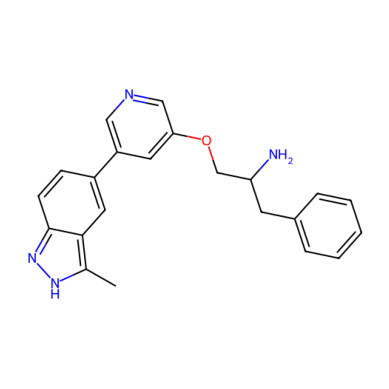

In [168]:
##############################################################
# 19.8 Molecule
##############################################################

mol = drug_df.loc[0, "Molecule"]

image = Draw.MolToImage(
    mol,
    size=(500,500)
)

plt.imshow(image)

plt.axis("off")

plt.show()

In [169]:
##############################################################
# 19.9 Save
##############################################################

torch.save(

    explanation,

    CHECKPOINT_DIR / "sample_explanation.pt"

)

print("Explanation saved.")

Explanation saved.
